# Statistical significance checks on the pilot runs
50/100 questions, 20/50 template variations -> 1000/5000 total questions (20% of the benchmark)

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from gsm_benchmarker.results_analyser import MultiVariantMultiModelResultsAnalyser
from gsm_benchmarker.results_analyser.prompt_effect_analyser import PromptEffectAnalyser

plt.style.use('seaborn-v0_8-muted')
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
pp = Path("../../../../data/gsm-symbolic/outputs").resolve()
p_standard = pp / "mini_20x50x4__14_11/final"
p_sep = pp / 'mini_sep_new__20x50__20_12/final'
p_code = pp / 'mini_code_output_20x50__05_12/final'

In [3]:
mres_standard = MultiVariantMultiModelResultsAnalyser(p_standard)
mres_sep = MultiVariantMultiModelResultsAnalyser(p_sep)
mres_code = MultiVariantMultiModelResultsAnalyser(p_code)

100%|██████████| 5/5 [00:01<00:00,  2.63it/s]


In [4]:
pea_sep = PromptEffectAnalyser(mres_standard, mres_sep, "Anti-babbling prompt")
pea_code = PromptEffectAnalyser(mres_standard, mres_code, "Code output prompt")

### Do template variations ('main') cause statistically significant accuracy drop compared to original questions ('GSM8K')?
Let's see for the GSM-Symbolic prompt and code prompt separately.

In [5]:
# if current p value is below this threshold, re-run on the full dataset might give a p-value below 0.05
projected_alpha = 0.15

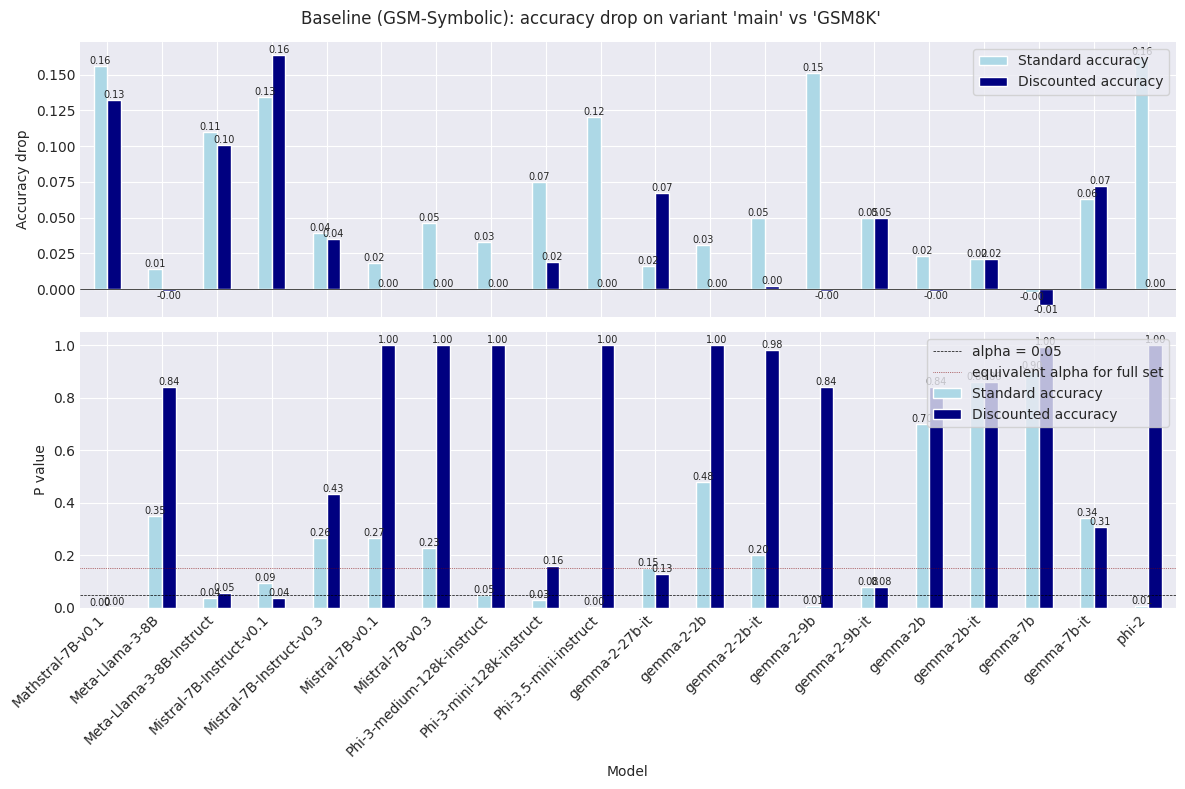

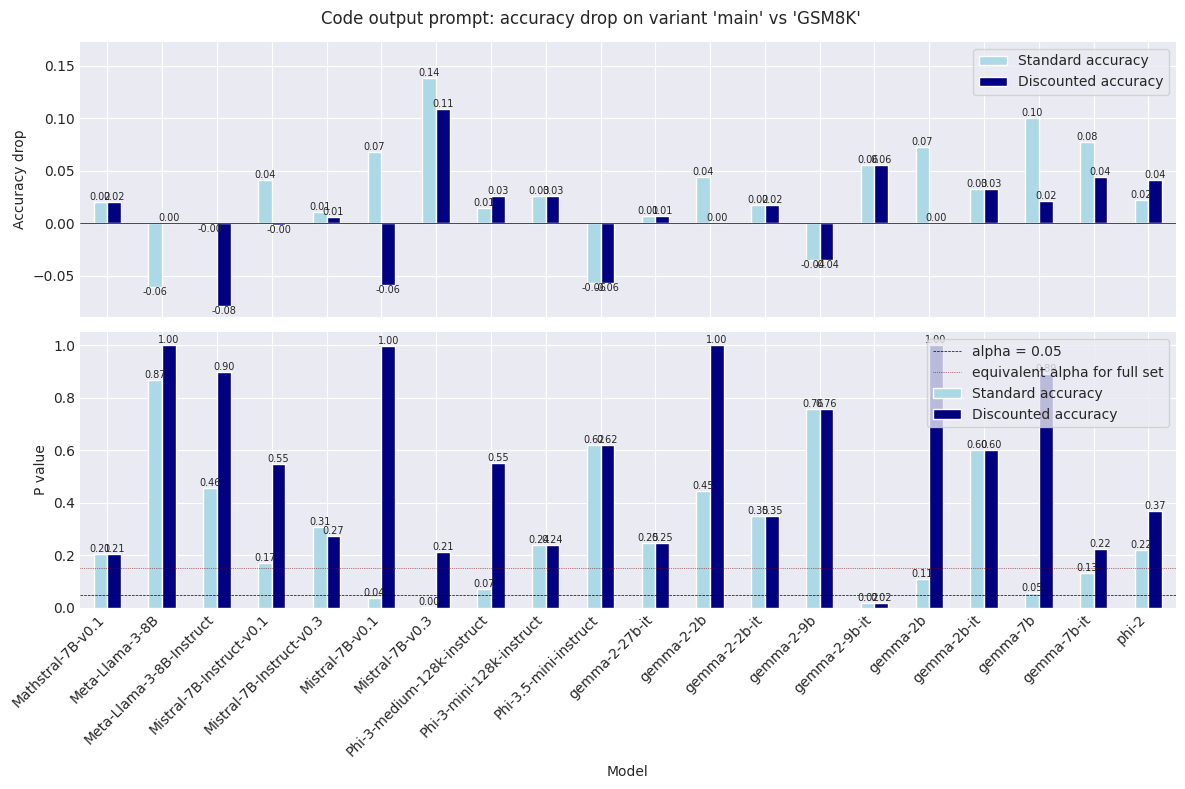

In [6]:
_, _, gap_significance_df = pea_code.plot_gap_significance_bars(projected_alpha=projected_alpha)

Does the code output prompt result in higher or lower accuracies than GSM-Symbolic prompt (on the template variations set)?

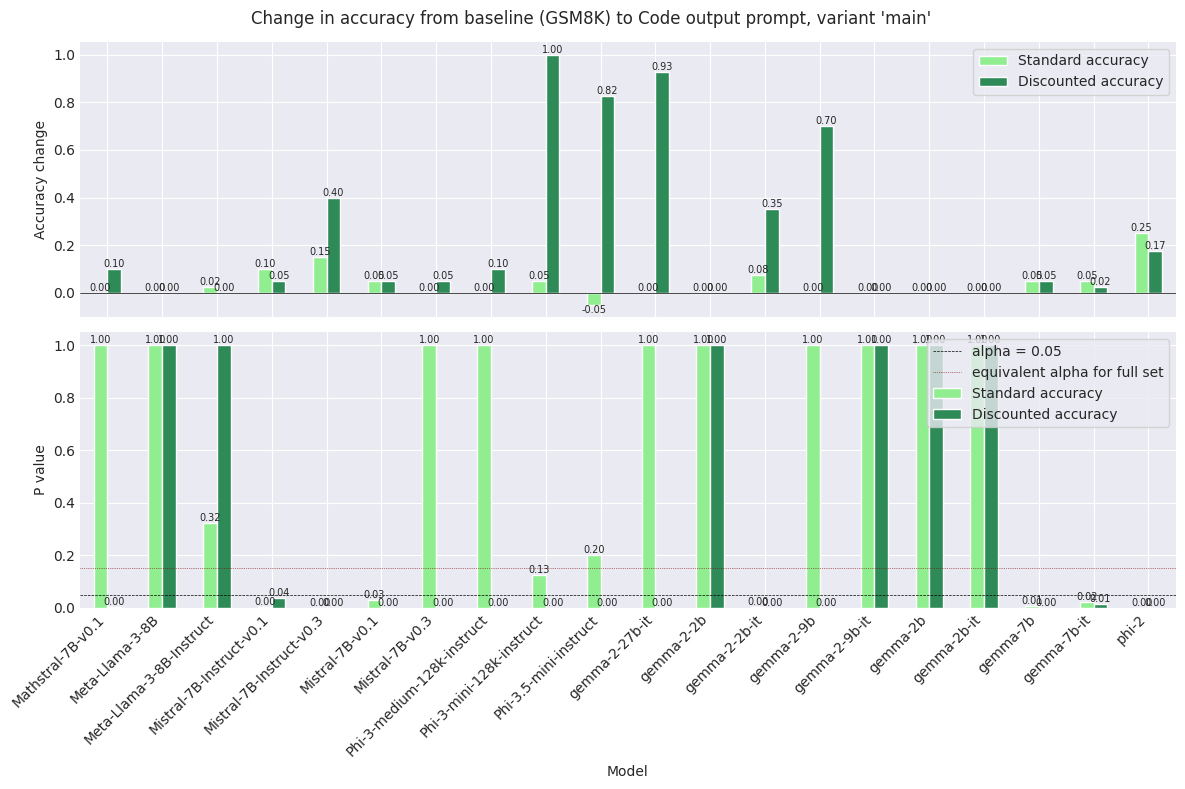

In [7]:
_ = pea_code.plot_accuracy_change_significance_bars('main', projected_alpha=projected_alpha)

For which models is the accuracy drop on GSM-Symbolic prompt statistically significant (or likely significant on full dataset)?

These will be re-run on the full dataset to see whether (a) the accuracy drop is indeed significant, (b) the code output prompt removes the accuracy drop.

In [8]:
candidates_df = gap_significance_df[gap_significance_df.baseline_p_value < projected_alpha]
candidates_df[['baseline_p_value', 'experiment_p_value']]

baseline_p_value  \
model                      metric                                  
Mathstral-7B-v0.1          Discounted accuracy          0.001426   
                           Standard accuracy            0.000021   
Meta-Llama-3-8B-Instruct   Discounted accuracy          0.054689   
                           Standard accuracy            0.036487   
Mistral-7B-Instruct-v0.1   Discounted accuracy          0.035154   
                           Standard accuracy            0.094711   
Phi-3-medium-128k-instruct Standard accuracy            0.047482   
Phi-3-mini-128k-instruct   Standard accuracy            0.028029   
Phi-3.5-mini-instruct      Standard accuracy            0.001409   
gemma-2-27b-it             Discounted accuracy          0.127634   
gemma-2-9b                 Standard accuracy            0.005964   
gemma-2-9b-it              Discounted accuracy          0.078772   
                           Standard accuracy            0.078772   
phi-2                      Standard accuracy            0.005029   

                                                experiment_p_value  
model                      metric                                   
Mathstral-7B-v0.1          Discounted accuracy            0.206561  
                           Standard accuracy              0.206561  
Meta-Llama-3-8B-Instruct   Discounted accuracy            0.899461  
                           Standard accuracy              0.456876  
Mistral-7B-Instruct-v0.1   Discounted accuracy            0.546831  
                           Standard accuracy              0.168894  
Phi-3-medium-128k-instruct Standard accuracy              0.072117  
Phi-3-mini-128k-instruct   Standard accuracy              0.237228  
Phi-3.5-mini-instruct      Standard accuracy              0.620457  
gemma-2-27b-it             Discounted accuracy            0.247543  
gemma-2-9b                 Standard accuracy              0.757665  
gemma-2-9b-it              Discounted accuracy            0.017325  
                           Standard accuracy              0.017325  
phi-2                      Standard accuracy              0.219183

In [9]:
list(candidates_df.index.get_level_values('model').unique())


['Mathstral-7B-v0.1',
 'Meta-Llama-3-8B-Instruct',
 'Mistral-7B-Instruct-v0.1',
 'Phi-3-medium-128k-instruct',
 'Phi-3-mini-128k-instruct',
 'Phi-3.5-mini-instruct',
 'gemma-2-27b-it',
 'gemma-2-9b',
 'gemma-2-9b-it',
 'phi-2']